# Evaluate apparent RESPIRATION extracted from AX3

The AX3s look to be capturing clapping and respiration relatively clearly, but to test whether this is actually the info of interst, we can compare the features of respiration extractedion from different dimensions evaluated on the same accelerometer. This is a test for respiration and criteria to exlcude intervals where the signal is too poor.


In [1]:
import sys
import os
import time
import datetime as dt
import math
import numpy as np 
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import emd

import rp2

from scipy.signal import butter, filtfilt, argrelextrema
from scipy import interpolate
from scipy.interpolate import interp1d
from scipy import ndimage
from scipy import signal

In [2]:
datapath = '/Users/finn/Desktop/Current_Projects/MotionComparisonPilot/QoM/smaled/'
# sources = os.listdir(datapath)
# print(sources)
sources = ['rgb','ir','thermalhandheld','thermalbox','therdata','ax3','jerk']
samplerates=dict(zip(sources,[59.97,59.97,25,50,4,400,10]))

ClapIMFs = pd.read_csv('/Users/finn/Desktop/Current_Projects/MotionComparisonPilot/QoM/Naive/acc_dimtest_Claps.csv',index_col=0)
Resps = pd.read_csv('/Users/finn/Desktop/Current_Projects/MotionComparisonPilot/QoM/Naive/acc_dimtest_RESP.csv',index_col=0)

# inconsitent sampling: therdata, ax3, jerk

In [43]:
# Down sample resp features to 20 Hz from 400Hz
RespIMFs = Resps.iloc[::20,:]
RespIMFs

,AU1_Z,AU1_Y,AU2_X,AU2_Z,AU3_Z,AU3_Y,AU4_Z,AU4_X,AU5_Z,AU7_Z
timestamp,,,,,,,,,,
60.0025,0.002015,0.001998,0.017320,0.005402,-0.001230,-0.002506,-0.063675,-0.026325,-0.000901,0.041846
60.0525,0.002806,0.002484,0.018010,0.005892,-0.001001,-0.001027,-0.061549,-0.024627,-0.000109,0.044518
60.1025,0.003764,0.002993,0.019031,0.006526,-0.000739,0.000970,-0.058805,-0.021960,0.000933,0.047784
60.1525,0.004729,0.003427,0.020199,0.007201,-0.000490,0.002942,-0.055900,-0.018717,0.002027,0.051009
60.2025,0.005571,0.003712,0.021327,0.007840,-0.000290,0.004456,-0.053160,-0.015316,0.002960,0.053659
...,...,...,...,...,...,...,...,...,...,...
414.7525,-0.017579,-0.001580,0.010920,-0.009739,0.019393,0.003427,0.007712,-0.002565,0.000353,0.007278
414.8025,-0.017145,-0.001849,0.011732,-0.010242,0.019929,0.003057,0.007169,-0.003264,0.000174,0.007628
414.8525,-0.016846,-0.002100,0.012398,-0.010664,0.020419,0.002745,0.006709,-0.003783,0.000016,0.007974


## Basic calculations to get from Acc to positional information more easily processed for respiration
On an oscillatory signal, acceleration is pi offset from location, which means that extrema and zero crossing align in time. To get back to position, we need to integrate twice. These accelerometers are not all that well calibrated per dimension, so we also need to correct the accumulating drift. This could be done with a highpass filter, or by substracting a low frequency component. Here I've settled on substracting a moving average that is smaller than the respiration wavelength but does not appear to distort the maxima too much. 

<Axes: xlabel='timestamp'>

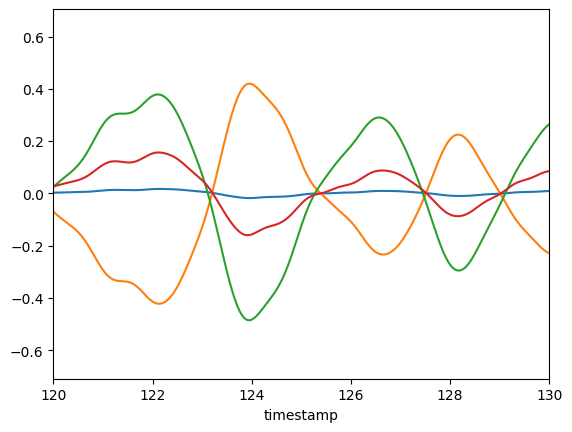

In [4]:
V = RespIMFs['AU1_Z'].copy()
V.plot()
V=V.cumsum().cumsum()
V  = V - V.rolling(25,center=True).mean()
V.plot()
V  = V.rolling(121,center=True).mean() - V   
V.plot()
V = RespIMFs['AU1_Z'].copy().cumsum().cumsum()
V  =V.rolling(15,center=True).mean() - V
plt.xlim([120,130])
plt.grid()
V.plot()

<Axes: xlabel='timestamp'>

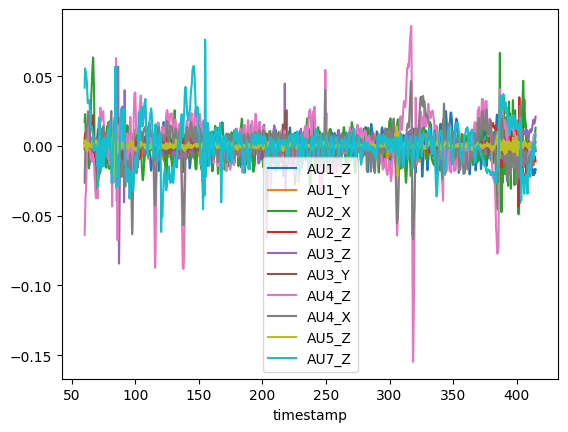

In [5]:
RespIMFs.plot()

In [8]:
roll_off = 25

# Respiration Information extraction per participant

Some participants showed respiration in one dimension, two dimensions or no dimensions of the accelerometer measurements. This treats each resp IMF as a respiration signal to show how clearly/reliably respiration was captured in these ACC signals per participant

In [44]:
cols = RespIMFs.columns
sf = 20
resp_feats = ['Period_T','Insp_T','IE_Ratio', 'IDepth','RelID']
xlim = [60,425]
vel_c = 0.2 # threshold for inspiration detection

86
[0.317 0.315 0.126 0.113 0.065 1.008]
91
91
85
[0.172 0.166 0.068 0.06  0.034 1.038]
93
93


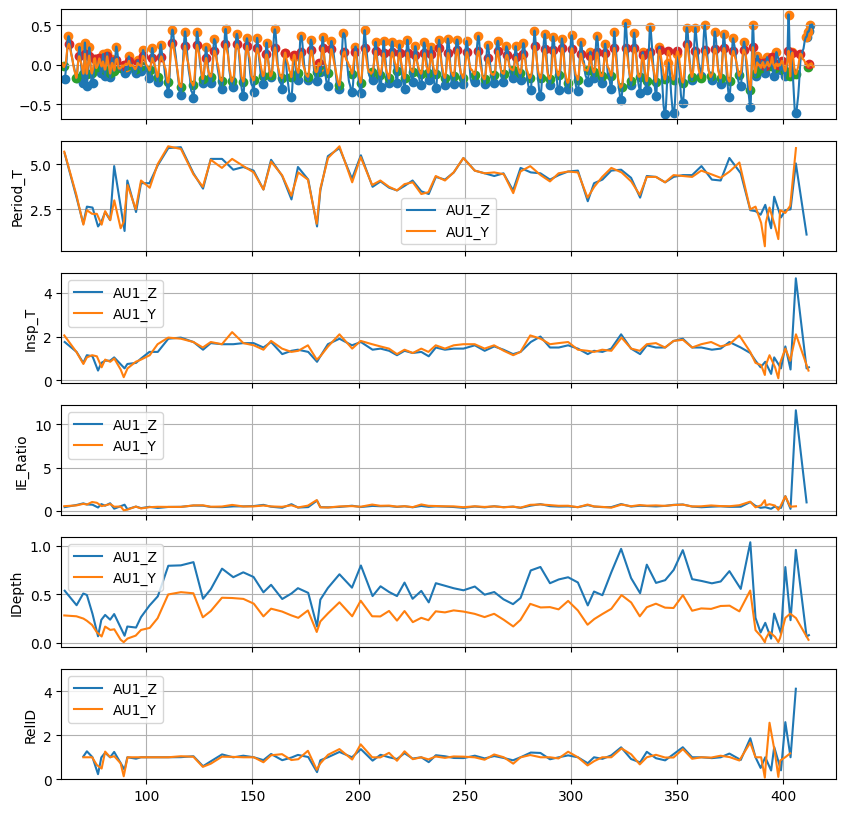

In [45]:
fig, axes = plt.subplots(1+len(resp_feats),1,sharex=True,figsize=(10,10))
for col in cols[:2]:
    R = pd.DataFrame()
    V = -RespIMFs[col].copy()
    if col.endswith('_Z'): V = RespIMFs[col].copy()#R['Breathing'] = -RespIMFs[col].copy()
    V = V.cumsum().cumsum()
    R['Breathing']= V - V.rolling(roll_off,center=True).mean()  
    Breaths = rp2.Inspiration_Extract(R['Breathing']) # old selections
    print(len(Breaths))
    newResp = R.copy()
    newResp['Filt'] = rp2.respnormed(R['Breathing'],scaling=1)
    newResp['Diff1'] = rp2.diffed(newResp['Filt'] )
    expansion_dist = newResp['Diff1'].loc[newResp['Diff1']>0].copy()*sf
    print(np.round([newResp['Diff1'].std()*sf,expansion_dist.median(),expansion_dist.quantile(0.25),expansion_dist.mean()*0.35,expansion_dist.mean()*0.2,newResp['Diff1'].std()*sf/expansion_dist.median()],3))
    skewstat = newResp['Diff1'].std()*sf/expansion_dist.median()
    Resp = rp2.unclip_minor(R['Breathing'].copy())
    Insps = rp2.Inspiration_Extract(Resp,False,vel_c,5)
    print(len(Insps))
    Breaths2 = rp2.breath_cycles(Insps,R['Breathing']) 
    print(len(Breaths2))
    R['Breathing'].plot(ax=axes[0])
    axes[0].scatter(Breaths2['In'],Breaths2['In_C'])
    axes[0].scatter(Breaths2['Ex'],Breaths2['Ex_C'])
    axes[0].grid() 
    for i in range(len(resp_feats)):
        c = resp_feats[i]
        if c.startswith('E'):
            axes[i+1].plot(Breaths2['Ex'],Breaths2[c],label = col)
        else:
            axes[i+1].plot(Breaths2['In'],Breaths2[c],label = col)

axes[len(resp_feats)].set_ylim([0,5])
axes[0].set_xlim(xlim)

for i in range(len(resp_feats)):
    c = resp_feats[i]
    axes[i+1].grid()  
    axes[i+1].legend() 
    axes[i+1].set_ylabel(c)
plt.savefig('./plots/'+ 'Resp_features_'+col.split('_')[0]+'.png',dpi = 300)
plt.show() 

For participant AU1, respiration rate was slower initially and the increased into more typical quiet breathing range until clapping distorted the signal. 

93
[0.454 0.364 0.172 0.135 0.077 1.248]
97
97
98
[0.189 0.08  0.037 0.039 0.022 2.363]
117
117


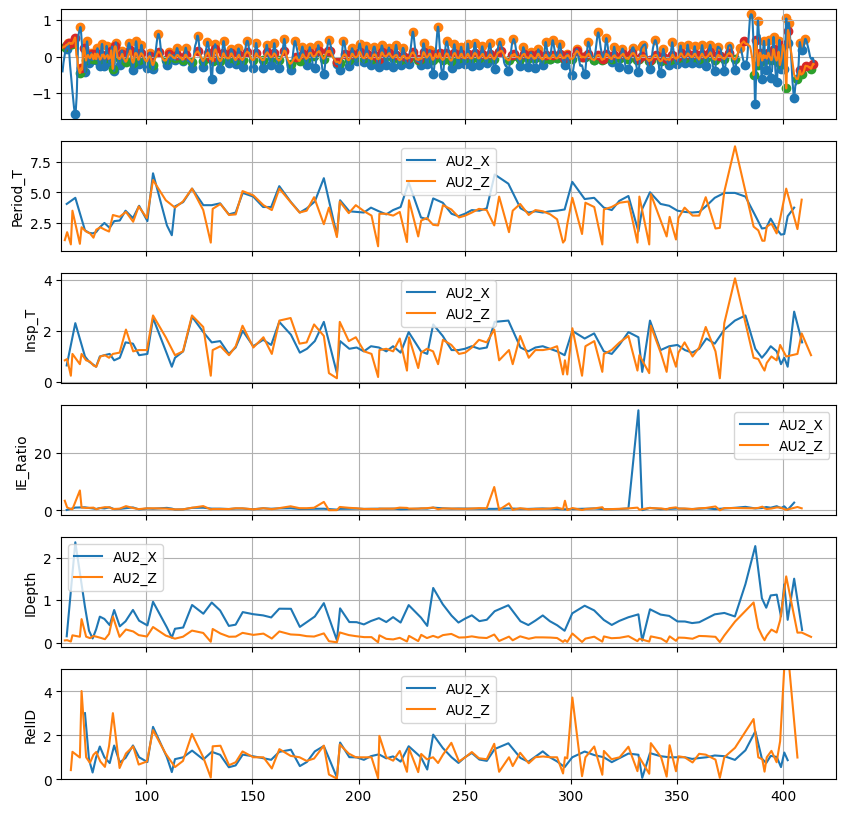

In [46]:
fig, axes = plt.subplots(1+len(resp_feats),1,sharex=True,figsize=(10,10))
for col in cols[2:4]:
    R = pd.DataFrame()
    V = RespIMFs[col].copy()
    if col.endswith('_Z'): V = -RespIMFs[col].copy()#R['Breathing'] = -RespIMFs[col].copy()
    V = V.cumsum().cumsum()
    R['Breathing'] = V - V.rolling(roll_off,center=True).mean()  
    Breaths = rp2.Inspiration_Extract(R['Breathing']) # old selections
    print(len(Breaths))
    newResp = R.copy()
    newResp['Filt'] = rp2.respnormed(R['Breathing'],scaling=1)
    newResp['Diff1'] = rp2.diffed(newResp['Filt'] )
    expansion_dist = newResp['Diff1'].loc[newResp['Diff1']>0].copy()*sf
    print(np.round([newResp['Diff1'].std()*sf,expansion_dist.median(),expansion_dist.quantile(0.25),expansion_dist.mean()*0.35,expansion_dist.mean()*0.2,newResp['Diff1'].std()*sf/expansion_dist.median()],3))
    skewstat = newResp['Diff1'].std()*sf/expansion_dist.median()
    Resp = rp2.unclip_minor(R['Breathing'].copy())   
    Insps = rp2.Inspiration_Extract(Resp,False,vel_c,5)
    print(len(Insps))
    Breaths2 = rp2.breath_cycles(Insps,R['Breathing']) 
    print(len(Breaths2))
    R['Breathing'].plot(ax=axes[0])
    axes[0].scatter(Breaths2['In'],Breaths2['In_C'])
    axes[0].scatter(Breaths2['Ex'],Breaths2['Ex_C'])
    axes[0].grid() 
    for i in range(len(resp_feats)):
        c = resp_feats[i]
        if c.startswith('E'):
            axes[i+1].plot(Breaths2['Ex'],Breaths2[c],label = col)
        else:
            axes[i+1].plot(Breaths2['In'],Breaths2[c],label = col)

axes[len(resp_feats)].set_ylim([0,5])
axes[0].set_xlim(xlim)

for i in range(len(resp_feats)):
    c = resp_feats[i]
    axes[i+1].grid()  
    axes[i+1].legend() 
    axes[i+1].set_ylabel(c)
plt.savefig('./plots/'+ 'Resp_features_'+col.split('_')[0]+'.png',dpi = 300)
plt.show() 

Participant AU2 was clearer in the X orientation. Respiration rate looks fairly stable over. Variation in middle section could be respiratory events (augmented breaths) or other motion.

112
[0.292 0.105 0.052 0.055 0.031 2.777]
132
132
117
[0.137 0.066 0.034 0.031 0.018 2.057]
134
134


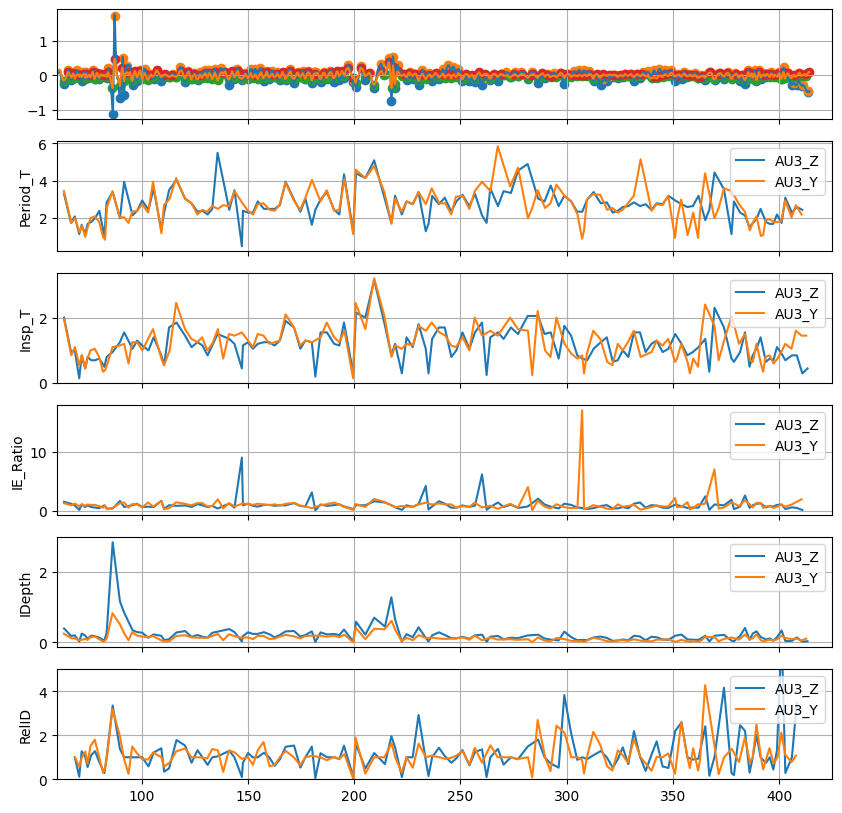

In [47]:
fig, axes = plt.subplots(1+len(resp_feats),1,sharex=True,figsize=(10,10))
xlim = [60,425]
for col in cols[4:6]:
    R = pd.DataFrame()
    V = -RespIMFs[col].copy()
    if col.endswith('_Z'): V = RespIMFs[col].copy()#R['Breathing'] = -RespIMFs[col].copy()
        
    V = V.cumsum().cumsum()
    R['Breathing'] = V - V.rolling(roll_off,center=True).mean()   
    Breaths = rp2.Inspiration_Extract(R['Breathing']) # old selections
    print(len(Breaths))
    newResp = R.copy()
    newResp['Filt'] = rp2.respnormed(R['Breathing'],scaling=1)
    newResp['Diff1'] = rp2.diffed(newResp['Filt'] )
    expansion_dist = newResp['Diff1'].loc[newResp['Diff1']>0].copy()*sf
    print(np.round([newResp['Diff1'].std()*sf,expansion_dist.median(),expansion_dist.quantile(0.25),expansion_dist.mean()*0.35,expansion_dist.mean()*0.2,newResp['Diff1'].std()*sf/expansion_dist.median()],3))
    skewstat = newResp['Diff1'].std()*sf/expansion_dist.median()
    Resp = rp2.unclip_minor(R['Breathing'].copy())
    Insps = rp2.Inspiration_Extract(Resp,False,vel_c,5)
    print(len(Insps))
    Breaths2 = rp2.breath_cycles(Insps,R['Breathing']) 
    print(len(Breaths2))
    R['Breathing'].plot(ax=axes[0])
    axes[0].scatter(Breaths2['In'],Breaths2['In_C'])
    axes[0].scatter(Breaths2['Ex'],Breaths2['Ex_C'])
    axes[0].grid() 
    for i in range(len(resp_feats)):
        c = resp_feats[i]
        if c.startswith('E'):
            axes[i+1].plot(Breaths2['Ex'],Breaths2[c],label = col)
        else:
            axes[i+1].plot(Breaths2['In'],Breaths2[c],label = col)

axes[len(resp_feats)].set_ylim([0,5])
axes[0].set_xlim(xlim)

for i in range(len(resp_feats)):
    c = resp_feats[i]
    axes[i+1].grid()  
    axes[i+1].legend() 
    axes[i+1].set_ylabel(c)

plt.show() 

For Participant AU3, the signal appears to be less clear, particularly in the second half. There is some breathing, but it looks intermittent in its visibility. Z is the more reasonable direction, depsite the instability

100
[0.563 0.251 0.116 0.127 0.072 2.245]
Clipped!
11
11
109
[0.383 0.232 0.099 0.101 0.058 1.651]
117
117


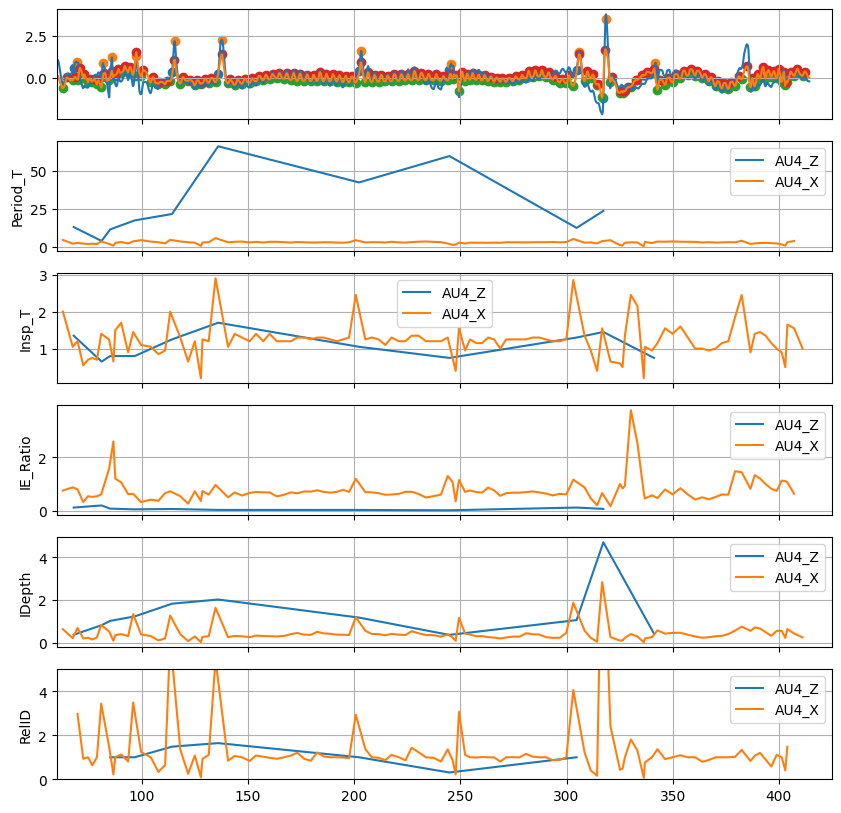

In [48]:
fig, axes = plt.subplots(1+len(resp_feats),1,sharex=True,figsize=(10,10))
xlim = [60,425]
for col in cols[6:8]:
    R = pd.DataFrame()
    V = RespIMFs[col].copy()    
    V = V.cumsum().cumsum()
    R['Breathing']= V - V.rolling(roll_off,center=True).mean()  
    Breaths = rp2.Inspiration_Extract(R['Breathing']) # old selections
    print(len(Breaths))
    newResp = R.copy()
    newResp['Filt'] = rp2.respnormed(R['Breathing'],scaling=1)
    newResp['Diff1'] = rp2.diffed(newResp['Filt'] )
    expansion_dist = newResp['Diff1'].loc[newResp['Diff1']>0].copy()*sf
    print(np.round([newResp['Diff1'].std()*sf,expansion_dist.median(),expansion_dist.quantile(0.25),expansion_dist.mean()*0.35,expansion_dist.mean()*0.2,newResp['Diff1'].std()*sf/expansion_dist.median()],3))
    skewstat = newResp['Diff1'].std()*sf/expansion_dist.median()
    Resp = rp2.unclip_minor(R['Breathing'].copy())
    Insps = rp2.Inspiration_Extract(Resp,False,vel_c,5)
    print(len(Insps))
    Breaths2 = rp2.breath_cycles(Insps,R['Breathing']) 
    print(len(Breaths2))
    R['Breathing'].plot(ax=axes[0])
    axes[0].scatter(Breaths2['In'],Breaths2['In_C'])
    axes[0].scatter(Breaths2['Ex'],Breaths2['Ex_C'])
    axes[0].grid() 
    for i in range(len(resp_feats)):
        c = resp_feats[i]
        if c.startswith('E'):
            axes[i+1].plot(Breaths2['Ex'],Breaths2[c],label = col)
        else:
            axes[i+1].plot(Breaths2['In'],Breaths2[c],label = col)

axes[len(resp_feats)].set_ylim([0,5])
axes[0].set_xlim(xlim)

for i in range(len(resp_feats)):
    c = resp_feats[i]
    axes[i+1].grid()  
    axes[i+1].legend() 
    axes[i+1].set_ylabel(c)

plt.savefig('./plots/'+ 'Resp_features_'+col.split('_')[0]+'.png',dpi = 300)
plt.show() 

AU4 showed a relatively high respiratory rate, even for quiet breathing, with some disruptions which could be augmented breaths or posture changes. The signal was clearer in the X dimension.

150
[0.084 0.025 0.012 0.014 0.008 3.316]
222
222


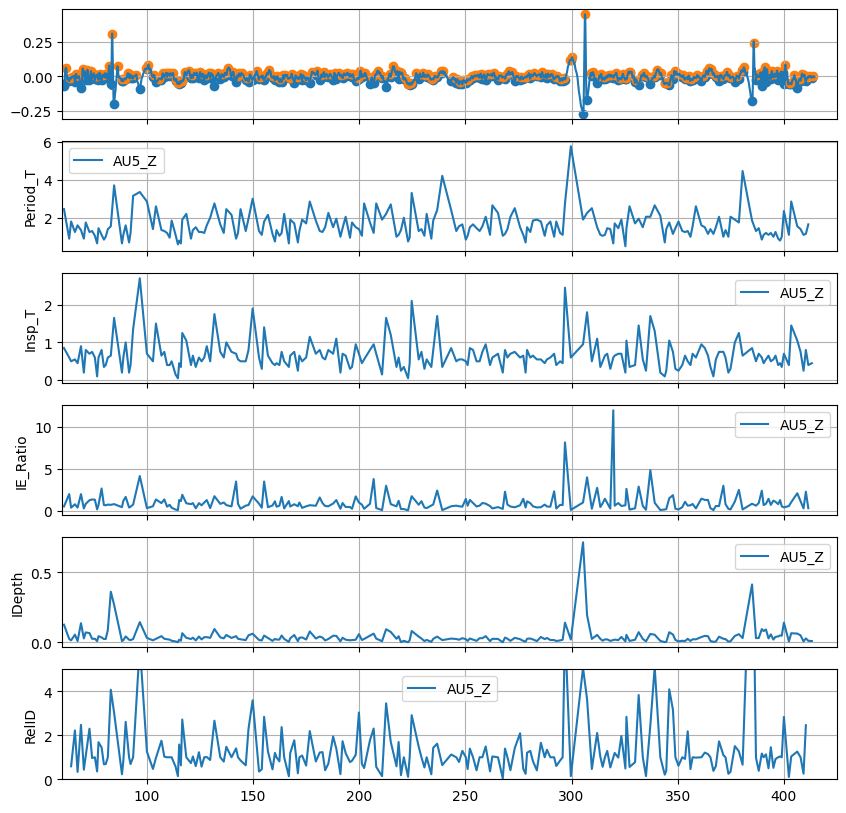

In [49]:
fig, axes = plt.subplots(1+len(resp_feats),1,sharex=True,figsize=(10,10))
xlim = [60,425]
col = cols[8]
R = pd.DataFrame()
V = RespIMFs[col].copy()    
V = V.cumsum().cumsum()
R['Breathing']= V - V.rolling(roll_off,center=True).mean()  
# if col.endswith('_Z'): R['Breathing'] = -RespIMFs[col].copy()
V = RespIMFs[col].copy()    
V = V.cumsum().cumsum()
Breaths = rp2.Inspiration_Extract(R['Breathing']) # old selections
print(len(Breaths))
newResp = R.copy()
newResp['Filt'] = rp2.respnormed(R['Breathing'],scaling=1)
newResp['Diff1'] = rp2.diffed(newResp['Filt'] )
expansion_dist = newResp['Diff1'].loc[newResp['Diff1']>0].copy()*sf
print(np.round([newResp['Diff1'].std()*sf,expansion_dist.median(),expansion_dist.quantile(0.25),expansion_dist.mean()*0.35,expansion_dist.mean()*0.2,newResp['Diff1'].std()*sf/expansion_dist.median()],3))
Resp = rp2.unclip_minor(R['Breathing'].copy())
Insps = rp2.Inspiration_Extract(Resp,False,vel_c,5)
print(len(Insps))
Breaths2 = rp2.breath_cycles(Insps,R['Breathing']) 
print(len(Breaths2))
R['Breathing'].plot(ax=axes[0])
axes[0].scatter(Breaths2['In'],Breaths2['In_C'])
axes[0].scatter(Breaths2['Ex'],Breaths2['Ex_C'])
axes[0].grid() 
for i in range(len(resp_feats)):
    c = resp_feats[i]
    if c.startswith('E'):
        axes[i+1].plot(Breaths2['Ex'],Breaths2[c],label = col)
    else:
        axes[i+1].plot(Breaths2['In'],Breaths2[c],label = col)

axes[len(resp_feats)].set_ylim([0,5])
axes[0].set_xlim(xlim)

for i in range(len(resp_feats)):
    c = resp_feats[i]
    axes[i+1].grid()  
    axes[i+1].legend() 
    axes[i+1].set_ylabel(c)
plt.savefig('./plots/'+ 'Resp_features_'+col.split('_')[0]+'.png',dpi = 300)

plt.show() 

The accelerometer did not pick up on Participant 5's respiration. The oscillations here are not the right shape or plausible in rate for a human adult at rest. This absense of informatin emphasises how capturing respiration with displacement from one point on the body can easily miss the signal of interest.

104
[0.362 0.208 0.089 0.093 0.053 1.743]
117
117


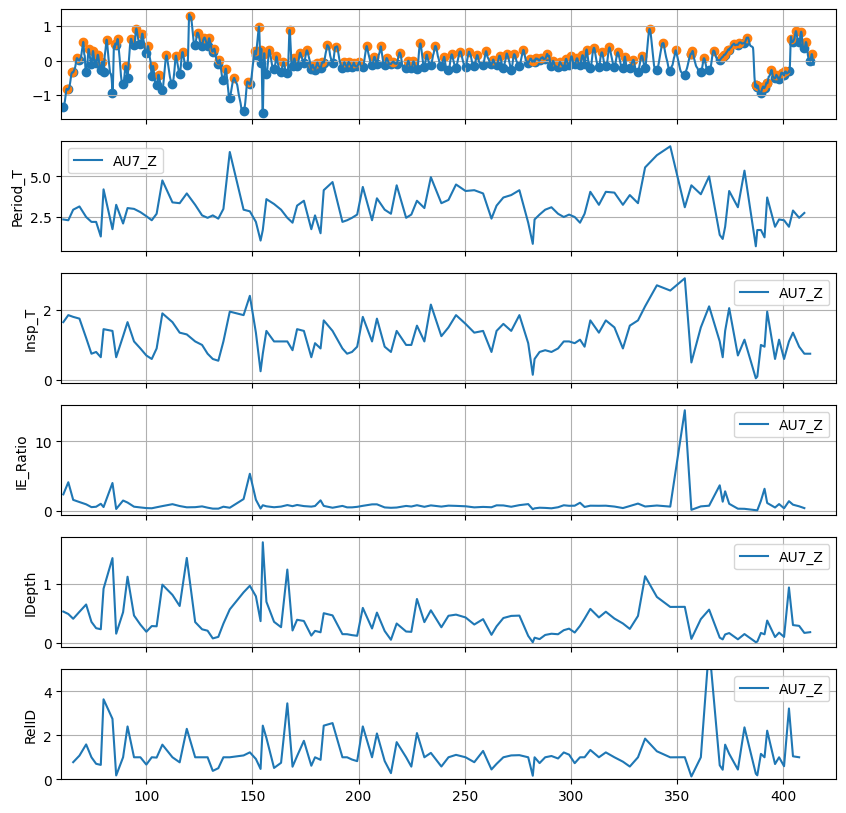

In [50]:
fig, axes = plt.subplots(1+len(resp_feats),1,sharex=True,figsize=(10,10))
xlim = [60,425]
col = cols[9]
R = pd.DataFrame()
V = RespIMFs[col].copy()
V = V.cumsum().cumsum()
R['Breathing'] = V - V.rolling(roll_off,center=True).mean()  
Breaths = rp2.Inspiration_Extract(R['Breathing']) # old selections
print(len(Breaths))
newResp = R.copy()
newResp['Filt'] = rp2.respnormed(R['Breathing'],scaling=1)
newResp['Diff1'] = rp2.diffed(newResp['Filt'] )
expansion_dist = newResp['Diff1'].loc[newResp['Diff1']>0].copy()*sf
print(np.round([newResp['Diff1'].std()*sf,expansion_dist.median(),expansion_dist.quantile(0.25),expansion_dist.mean()*0.35,expansion_dist.mean()*0.2,newResp['Diff1'].std()*sf/expansion_dist.median()],3))
Resp = rp2.unclip_minor(R['Breathing'].copy())
Insps = rp2.Inspiration_Extract(Resp,False,vel_c,5)
print(len(Insps))
Breaths2 = rp2.breath_cycles(Insps,R['Breathing']) 
print(len(Breaths2))
R['Breathing'].plot(ax=axes[0])
axes[0].scatter(Breaths2['In'],Breaths2['In_C'])
axes[0].scatter(Breaths2['Ex'],Breaths2['Ex_C'])
axes[0].grid() 
for i in range(len(resp_feats)):
    c = resp_feats[i]
    if c.startswith('E'):
        axes[i+1].plot(Breaths2['Ex'],Breaths2[c],label = col)
    else:
        axes[i+1].plot(Breaths2['In'],Breaths2[c],label = col)

axes[len(resp_feats)].set_ylim([0,5])
axes[0].set_xlim(xlim)

for i in range(len(resp_feats)):
    c = resp_feats[i]
    axes[i+1].grid()  
    axes[i+1].legend() 
    axes[i+1].set_ylabel(c)
plt.savefig('./plots/'+ 'Resp_features_'+col.split('_')[0]+'.png',dpi = 300)
plt.show() 

The repsiration rate looks high and some inspiration intervals seem unreasonable large which could be controlled respiration (330s-355s) or interference from another type of motion.

# Plotting respiration features from each participant
Selecting the best performing dimension of acceleration per participant, plot the extracted features together.

These plots show where the respiration information disappears when the features fall into unrealistic ranges for the behaviour of these participants. Clapping clearly interfered with the signal. The discerning posture change effects from augmented breaths is not possible from the vantage, so some of those spikes should be treated as ambiguous. 

Duration features show how these components of the accelerometer measurements are breathing related. Depth dependent features (including inspiration velocity) have very little absolute value in these measurements but the stability in their time series reflect regularity expected from quiet attentive breathing. 

86
[0.317 0.315 0.126 0.113 0.065 1.008]
91
91
93
[0.454 0.364 0.172 0.135 0.077 1.248]
97
97
112
[0.292 0.105 0.052 0.055 0.031 2.777]
132
132
109
[0.383 0.232 0.099 0.101 0.058 1.651]
117
117
104
[0.362 0.208 0.089 0.093 0.053 1.743]
117
117


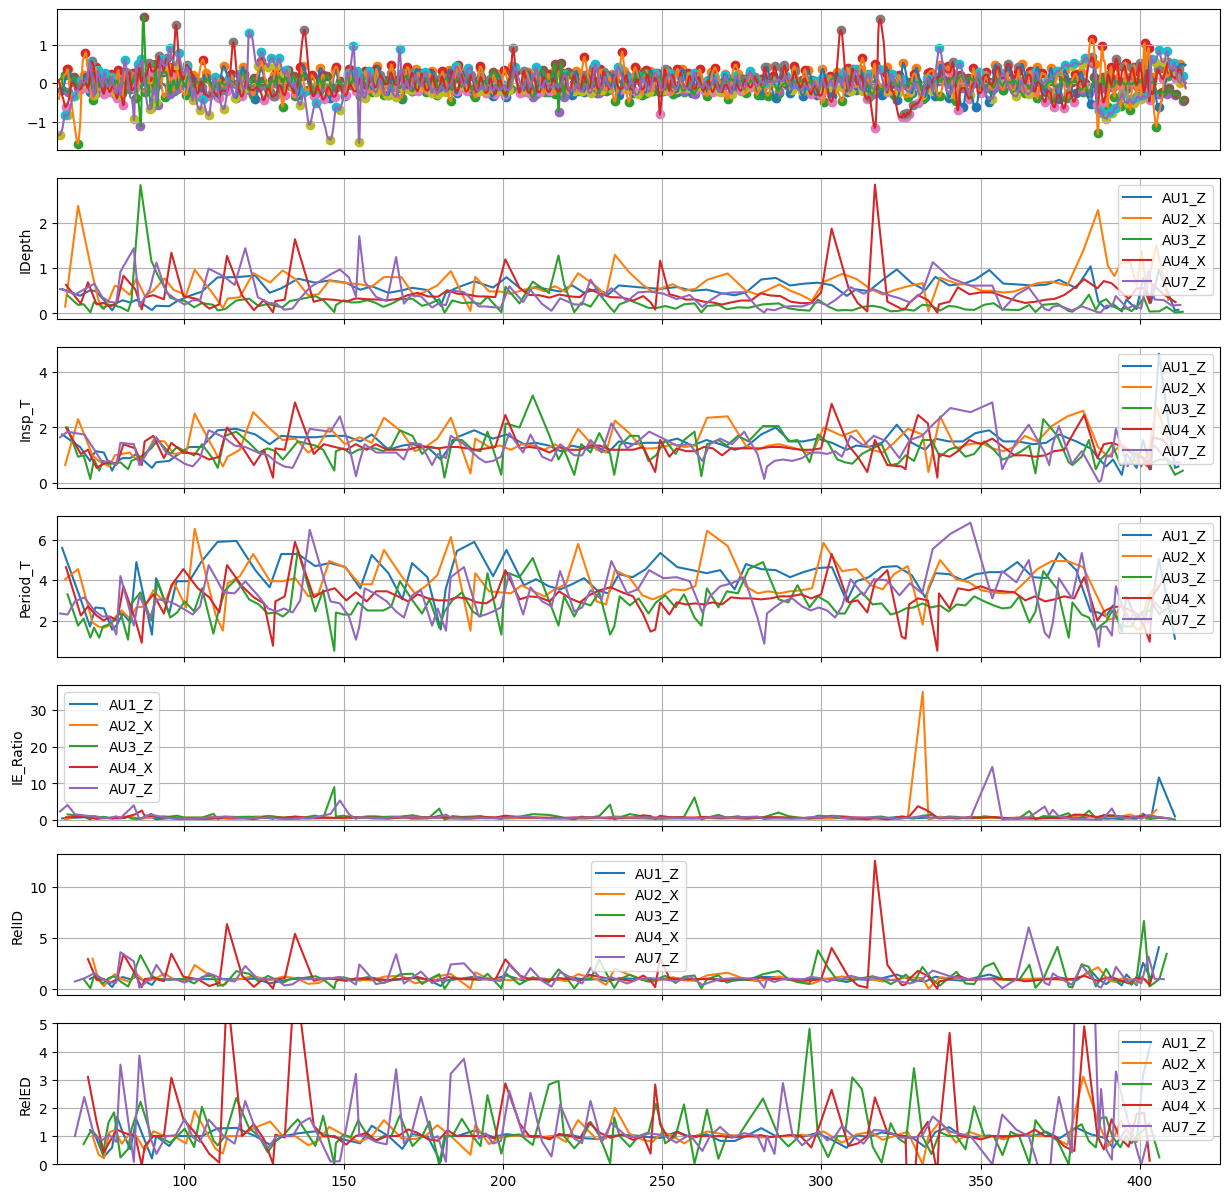

In [51]:
resp_feats = ['IDepth', 'Insp_T', 'Period_T','IE_Ratio','RelID', 'RelED']
sub_cols = ['AU1_Z', 'AU2_X', 'AU3_Z', 'AU4_X', 'AU7_Z']
fig, axes = plt.subplots(1+len(resp_feats),1,sharex=True,figsize=(15,15))
xlim = [60,425]
for col in sub_cols:
    R = pd.DataFrame()
    V = RespIMFs[col].copy()
    V = V.cumsum().cumsum()
    R['Breathing']= V - V.rolling(roll_off,center=True).mean()  
    
    Breaths = rp2.Inspiration_Extract(R['Breathing']) # old selections
    print(len(Breaths))
    newResp = R.copy()
    newResp['Filt'] = rp2.respnormed(R['Breathing'],scaling=1)
    newResp['Diff1'] = rp2.diffed(newResp['Filt'] )
    expansion_dist = newResp['Diff1'].loc[newResp['Diff1']>0].copy()*sf
    print(np.round([newResp['Diff1'].std()*sf,expansion_dist.median(),expansion_dist.quantile(0.25),expansion_dist.mean()*0.35,expansion_dist.mean()*0.2,newResp['Diff1'].std()*sf/expansion_dist.median()],3))
    Resp = rp2.unclip_minor(R['Breathing'].copy())
    Insps = rp2.Inspiration_Extract(Resp,False,vel_c,5)
    print(len(Insps))
    Breaths2 = rp2.breath_cycles(Insps,R['Breathing']) 
    print(len(Breaths2))
    R['Breathing'].plot(ax=axes[0])
    axes[0].scatter(Breaths2['In'],Breaths2['In_C'])
    axes[0].scatter(Breaths2['Ex'],Breaths2['Ex_C'])
    axes[0].grid() 
    for i in range(len(resp_feats)):
        c = resp_feats[i]
        if c.startswith('E'):
            axes[i+1].plot(Breaths2['Ex'],Breaths2[c],label = col)
        else:
            axes[i+1].plot(Breaths2['In'],Breaths2[c],label = col)

axes[len(resp_feats)].set_ylim([0,5])
axes[0].set_xlim(xlim)

for i in range(len(resp_feats)):
    c = resp_feats[i]
    axes[i+1].grid()  
    axes[i+1].legend() 
    axes[i+1].set_ylabel(c)
plt.savefig('./plots/'+ 'Resp_features_5parts.png',dpi = 300)

plt.show() 

No respiration info from AU5

## reliability

In five of six participants, some respiration was captured by the flank-mounted accelerometer.

The respiration signal is recognisable from the rate of oscillation, the unevenness between inspriation and espiration, with inspiration times being shorter and usually in range of 1 second (suitable for attentive quiet breathing)

The analysis was performed after individual dimensions of acceleration were decomposed for Imperical Mode Functions with anchor frequences of []. Respriation was recomposed using the middle range of components (4-6), leaving the highest and lowest components behind. This strategy for seperating respiration from the original 400 Hz signals was a rough adaptation just to clarify the energy of actions with expectedly variable frequencies in distinct ranges. Following this recomposition, the extracted respiration wave was downsampled to 20 Hz for faster processing. 

Without a more reliable comparison signal, we can't make strong claims to the quality of the respiration recording, however the surviving information is enough to confirm the signal from wave shape and rate. The some measurements show instability in respiratory period that looks like interference from a slow frequency noise source. 

Flank mounted accelerometers aren't the most reliable way of measuring respiratory activity, but they captures some while the camera based measurements of quantity of motion did not. Considering the fastest camera frame rates were above that used for the respiration signal feature extraction, we can assume that either the framewise differences on participants motion failed to expose this subtle displacement or the spatial resolution of participants made such movements to small for the cameras to capture at all. 